# 梯度范数（Gradient Norm） 
- 是深度学习中用于衡量模型参数梯度向量"大小"或"长度"的标量指标，它反映了当前迭代中模型<font color='red'>参数更新的强度</font>

## 数学定义
梯度范数通常采用 L2 范数（欧几里得范数） 计算，公式为：

In [2]:
from IPython.display import Image

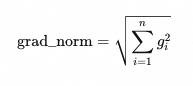

In [3]:
Image(filename='./Image/grad_norm.png')

-  $g_i$是第 i 个参数的梯度值， 
- n 是参数总数。

直观理解：<font color='red'>把模型所有参数的梯度展平拼接成一个大向量，然后计算这个向量的"长度"</font>

## 梯度范数的物理含义
<font color='red'>梯度范数本质上衡量的是"模型这一步想走多远"</font>：

  - 范数太小（如 < 0.1）：模型认为当前状态已经很好，或者信号太弱，<font color='red'>参数几乎不更新，学习停滞（可能是梯度消失）。</font>
  - <font color='blue'>范数适中（如 0.1 ~ 10）</font>：**模型在稳定学习**，这是期望的状态。
  - <font color='red'>范数太大（如 > 10）</font>：模型认为当前错误严重，想要大幅修改参数，容易导致参数剧烈跳变甚至训练崩溃（梯度爆炸）。
  
⚠️ 注意：梯度范数的绝对大小不能跨模型直接比较，**不同模型结构、参数规模、损失函数都会影响其数值**。通常需要先建立同一模型下的健康基线，再关注相对变化。

## 核心作用

### 监控训练稳定性
**通过观察梯度范数的变化趋势，可以判断训练是否健康：**
  - 正常：梯度范数在训练初期波动较大，随着训练进入稳定阶段逐渐变得平滑且数值较低
  - 异常：出现突然的尖峰（Spike），可能预示梯度爆炸风险，需要检查数据批次或奖励信号
  
### 梯度裁剪（Gradient Clipping）的依据
这是梯度范数最直接的工程应用。<font color='red'>当梯度范数**超过预设阈值 max_norm 时**，按比例缩放所有梯度：</font>

$g_i^′=g_i ×  \frac{max_norm}{max(grad_norm,max_norm)}$

<font color='red'>这样既保留了梯度的方向，又限制了更新幅度，防止参数被异常样本"带偏"。</font>

### 判断收敛状态
当模型接近最优解时，梯度范数会自然趋近于 0（因为梯度指向损失下降最快的方向，接近谷底时坡度变缓）。但需要注意，训练中后期全局梯度范数变小也可能是正常的收敛现象，不能仅凭此判断梯度消失。

## 与其他范数的关系
梯度范数中的"范数"是一个通用概念，除了最常用的 L2 范数外，还有：

| 范数类型 | 计算方式 | 特点 |
|---------|---------|------|
| L1 范数 | 所有梯度绝对值之和 | 对异常值更鲁棒 |
| L2 范数 | 梯度平方和的**平方根** | 最常用，可微 |
| L∞ 范数 | 梯度中的**最大绝对值** | 关注最极端的梯度分量 |

<font color='red'>在深度学习实践中，L2 范数是默认选择，因为它具有良好的几何直觉（欧几里得距离）和数学性质（可微）。</font>

## 一句话总结
- 梯度范数就是模型参数更新的"力度计"
  - 它告诉你模型在当前这一步想要"走多远"，是判断训练是否健康、是否需要干预的核心指标。
  
## GRPO 的梯度是怎么来的？
GRPO 的核心流程是这样的：
1. 对同一个 Prompt，采样 G 个输出（比如你说的 5 个）
2. 分别计算每个输出的奖励 r_i
3. 计算组内均值 μ 和标准差 σ ，得到每个输出的优势值： Ai=(r_i−μ)/(σ+ϵ)
4. 将 5 个输出的损失聚合成一个总 Loss
5. 对这个总 Loss 做一次 backward()，得到一组全局梯度
6. <font color='red'>计算这组全局梯度的范数 → 这就是你监控的那个梯度范数</font>

# 梯度范数的合理范围

- 取决于训练阶段、模型规模、网络架构和任务类型，没有统一的“标准答案”；
- 通用参考区间为：
  - 正常训练 0.1\~1.0，警告区间 1.0\~10.0，梯度爆炸 >10.0。

具体分场景与诊断标准如下：

## 📊 不同场景下的参考范围
  - <font color='red'>强化学习（PPO 等策略梯度方法）：</font>
    - 裁剪阈值（max_norm）通常设在 0.5~2.0 之间。
      - PPO 大模型对齐场景中常见值为 0.5；
      - GAIL-PPO 判别器训练约 0.75；
      - PPO-LSTM 仿真场景约 0.8；
      - 四足机器人非平坦地形训练中甚至低至 0.3
      
  - 大模型训练（7B 规模、BF16、AdamW）：
    - 正常训练的梯度范数稳定在 0.1~1.0 区间；超过 1.0 且持续上升属于警告区间；超过 10 判定为梯度爆炸。
  - 通用深度学习微调（SFT/DPO）：
    - 梯度裁剪默认值通常设在 1.0~2.0，出现 NaN 或损失骤升时降低至 1.0。
  
## 📌 关键认知：裁剪阈值 ≠ 实际梯度范数
  - **max_norm 是“天花板”：**
    - 它规定的是“允许的最大梯度长度”，不是“期望的梯度大小”。<font color='red'>实际梯度范数通常远低于这个值</font>
  - **裁剪是等比缩放**
    - ：<font color='red'>当实际梯度范数超过 max_norm 时，PyTorch 会按比例缩小所有梯度，保持方向不变，只缩短长度</font>。例如 max_norm=0.5 时，若裁剪前梯度范数为 22.58，则整体缩小约 45 倍，平均只保留原梯度的约 2.2%。
  - **0.5 是经验值：**
    - 在 PPO 等 RL 实现中 0.5 非常常见，但它不是数学定律，需要根据具体任务调整。
    
## 🔍 梯度范数的诊断意义
梯度范数在训练不同阶段的表现蕴含重要诊断信息：
  - 训练初期：梯度范数波动较大是正常的，**因为策略还在快速探索**。
  - 稳定阶段：<font color='red'>梯度范数应变得平滑且数值较低，表明更新平稳。</font>
  - <font color='red'>出现尖峰：可能预示梯度爆炸风险，**需要检查数据批次或奖励信号。**</font>
  - 持续为零：说明模型已停止学习（参数冻结或优势值归零）。
  - V 形曲线（先降后升）：通常与特定数据批次相关，需要排查数据质量。
  
## 📋 实用监控阈值表（7B 规模大模型训练）

| 信号 | 正常区间 | 警告线 | 发散线 |
|------|----------|--------|--------|
| 梯度范数 | 0.1 ~ 1.0 | 1.0 ~ 10 | > 10 |
| loss 与基线比值 | 0.8 ~ 1.2 | 2 倍 | 3 倍 |
| 权重 NaN 占比 | 0 | 0 | > 0 |
| 连续异常 step 数 | 0 | 2 | 5 |



## 🛠️ 实操建议
  - 起步设置：
    - PPO 大模型对齐建议 max_norm=0.5；通用微调建议 max_norm=1.0。
  - 监控策略：
    - 每 N 步记录梯度范数，绘制时间序列图，**观察是否稳定在正常区间。**
  - 异常响应：
    - 梯度范数超过 10 → 立即启用梯度裁剪（max_norm=1.0）+ 学习率衰减到当前值的 1/10 + 跳过异常数据批次，后续 500 步稳定后恢复原学习率。
  - 调参方向：
    - 如果梯度范数长期被裁剪（实际值频繁触及 max_norm），说明 max_norm 设得太低，可以适当放宽；
    - 如果梯度范数频繁出现尖峰，说明数据或奖励信号有问题，优先排查数据质量。
    
## 总结：
- 梯度范数的“合理范围”本质上是训练稳定性的晴雨表。
  - 与其追求一个固定数值，不如建立自己的基线
    - <font color='red'>记录训练前 100 步的梯度范数中位数作为基线，后续只要波动在基线的 2~3 倍以内，就可以认为训练处于健康状态。</font>

# 梯度范数出现尖峰
- 可能预示梯度爆炸风险，需要检查数据批次或奖励信号。

在深度强化学习（RL）的训练监控中，<font color='red'>梯度范数（Gradient Norm）出现尖峰（Spike） 是最危险的信号之一。</font>
- <font color='blue'>它通常意味着模型在某个瞬间接收到了极其强烈的“错误信号”或“过强反馈”，**导致参数更新步长瞬间失控**。</font>
- 如果不及时处理，这往往会导致模型参数被破坏（NaN）、Loss 变成无穷大，甚至训练彻底崩溃。

下面我将从现象本质、产生原因、具体案例三个维度详细解释，并给出排查建议。

##  现象**本质**：什么是“梯度尖峰”？
- 定义：在训练曲线图上，梯度范数平时维持在较低水平（如 0.1~1.0），<font color='blue'>但突然在某一步（Step）飙升到极高的值（如 50、100 甚至 1000），随后可能又迅速回落或导致训练中断。</font>
- 物理含义：
  - 梯度代表“**修正方向**”和“**修正力度**”。
  - 尖峰意味着模型在这一刻认为：“我错得离谱！”或者“这个样本太重要了！”，<font color='blue'>因此试图进行一次巨大的参数跳跃来修正误差。</font>
- 风险：神经网络的 Loss 曲面是非线性的。<font color='blue'>巨大的步长极易让模型直接跨过“最优谷底”，跳到另一个极高 Loss 的区域，甚至直接跳出有效定义域（导致数值溢出）。</font>

##  核心**原因**与**具体案例**
<font color='blue'>出现尖峰通常不是模型结构的问题</font>，<font color='red'>而是数据（Data）或奖励（Reward）的问题</font>。
以下是三个最典型的场景：

### 场景一：<font color='blue'>奖励信号未归一化（Reward Scaling 问题）</font>

这是最常见的原因。<font color='red'>如果环境给出的奖励值波动极大，梯度就会随之剧烈波动。</font>
- 举例：
  - 正常情况：智能体每走一步得 -1 分，到达终点得 +10 分。梯度变化是平滑的。
  - 异常情况：由于代码 Bug，智能体偶尔触发了一个隐藏彩蛋，系统错误地给了 +10000 分，或者因为除以了极小的时间步长导致奖励变成了 +50000 分。
- 后果：
  - 当这个 +50000 的样本进入 Batch 计算 Loss 时， Loss=−log(π)×50000 。
  - 反向传播时，梯度也会放大 50000 倍。原本应该是 0.01 的梯度更新，瞬间变成了 500。
  - 结果：<font color='red'>模型为了迎合这一个“天大奖励”，疯狂修改参数，导致之前学到的所有正常策略被瞬间覆盖（灾难性遗忘）。</font>
  
  
### 场景二：数据批次中的“脏数据”或“异常状态”

如果输入的状态（Observation）包含异常值，会导致网络激活值爆炸，进而导致梯度爆炸。
- 举例：
  - 背景：训练一个自动驾驶模型，输入是速度、距离等传感器数据。
  - 异常：某个传感器故障，传回了一个 NaN（非数字）或者极大的数值（如 999999）。或者在预处理时，某一张图片的像素值没有被归一化到 [0,1]，而是保留了原始的大整数。
- 后果：
  - <font color='blue'>这个巨大的输入值经过多层神经网络乘法后，会导致中间层的激活值（Activation）呈指数级增长。</font>
  - <font color='blue'>在反向传播时，根据链式法则，这些巨大的激活值会作为乘数传递给梯度，导致梯度范数瞬间飙升。</font>
  
### 场景三：重要性采样比率失控（PPO 特有）
正如你之前提到的 Ratio 问题，如果旧策略和新策略差异过大，也会导致梯度尖峰。
- 举例：
  - 旧策略认为动作 A 的概率是 0.0001（几乎不可能做）。
  - 新策略认为动作 A 的概率是 0.5（很想做的）。
  - 此时 Ratio=0.5/0.0001=<font color='red'>5000</font> 。
- 后果：
  - <font color='red'>即使有 Clip 机制，如果在 Clip 之前计算梯度，或者使用了其他未裁剪的辅助 Loss（如 Value Loss），这个 5000 倍的系数会直接乘在梯度上，形成尖峰。</font>

##  如何排查与解决？
当你看到梯度范数出现尖峰时，请按以下顺序操作：
1. 检查 Reward 分布（最优先）：
  - 打印当前 Batch 的 Reward 最大值和最小值。
  - 对策：对 Reward 进行归一化（Normalization）或裁剪（Clipping）。例如，强制限制单步奖励在 [-10, 10] 之间，或者使用 Running Mean 动态调整奖励尺度。
  
2. 实施梯度裁剪（Gradient Clipping）：
  - 这是防止尖峰破坏模型的最后一道防线。
  - 对策：设置一个全局梯度范数阈值（Global Norm Clipping），例如 PyTorch 中的 torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)。
  - 作用：如果梯度算出来是 100，强制把它缩放回 0.5。虽然这没有解决根本问题，但能保住模型不崩溃。
  
3. 检查数据管道：
  - 观察尖峰出现的时间点，回放当时的 Environment Step。
  - 对策：查看是否有传感器数值溢出、除以零错误、或者非法的状态输入。
4. 降低学习率：
  - 如果尖峰频繁出现且无法通过数据清洗解决，说明当前的学习率对于这个波动的梯度来说太大了。尝试将学习率降低一个数量级。

## 总结
- 梯度尖峰 = 数据的噪声或极端值被放大了。
- 不要试图通过调整网络结构来解决它，去检查你的数据清洗流程和奖励函数设计，通常能找到根源。

# 实现"前 100 步建立梯度范数基线，后续监控波动是否在 2~3 倍以内"的逻辑：

In [ ]:
import torch
import numpy as np
from collections import deque


class GradientNormMonitor:
    """
    梯度范数监控器
    - 前 warmup_steps 步：收集梯度范数，计算中位数作为基线
    - 后续步：判断当前梯度范数是否在基线的 healthy_range 倍以内
    """

    def __init__(self, warmup_steps=100, healthy_range=(2.0, 3.0)):
        self.warmup_steps = warmup_steps
        self.healthy_min, self.healthy_max = healthy_range

        self.step_count = 0
        self.baseline = None  # 基线（中位数）
        self.norm_history = []  # warmup 阶段收集的范数

    def compute_grad_norm(self, model):
        """计算模型所有参数的全局梯度范数"""
        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        return total_norm ** 0.5

    def update(self, model):
        """
        每次反向传播后、optimizer.step() 前调用
        返回: (grad_norm, status, message)
            status: 'warmup' | 'healthy' | 'warning' | 'danger'
        """
        grad_norm = self.compute_grad_norm(model)
        self.step_count += 1

        # ===== 阶段一：Warmup，收集基线 =====
        if self.step_count <= self.warmup_steps:
            self.norm_history.append(grad_norm)

            if self.step_count == self.warmup_steps:
                self.baseline = np.median(self.norm_history)
                print(f"[Monitor] 基线建立完成！"
                      f"中位数={self.baseline:.4f}, "
                      f"健康区间=[{self.baseline * self.healthy_min:.4f}, "
                      f"{self.baseline * self.healthy_max:.4f}]")

            return grad_norm, 'warmup', f"Warmup {self.step_count}/{self.warmup_steps}"

        # ===== 阶段二：正式监控 =====
        lower_bound = self.baseline * self.healthy_min
        upper_bound = self.baseline * self.healthy_max

        if grad_norm > upper_bound:
            status = 'danger'
            msg = (f"⚠️ 梯度尖峰！范数={grad_norm:.4f}, "
                   f"基线={self.baseline:.4f}, "
                   f"倍率={grad_norm / self.baseline:.1f}x "
                   f"(超过 {self.healthy_max}x 上限)")
        elif grad_norm < lower_bound:
            status = 'warning'
            msg = (f"⚡ 梯度过低！范数={grad_norm:.4f}, "
                   f"基线={self.baseline:.4f}, "
                   f"倍率={grad_norm / self.baseline:.1f}x "
                   f"(低于 {self.healthy_min}x 下限)")
        else:
            status = 'healthy'
            msg = (f"✅ 正常 | 范数={grad_norm:.4f}, "
                   f"倍率={grad_norm / self.baseline:.1f}x")

        return grad_norm, status, msg


# =============================================
# 使用示例：嵌入 PPO 训练循环
# =============================================

# 假设你已有 model, optimizer, env 等
# model = YourPolicyNetwork()
# optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

monitor = GradientNormMonitor(warmup_steps=100, healthy_range=(2.0, 3.0))

# for step in range(total_steps):
#     # 1. 前向传播 + 计算 Loss
#     obs = env.reset()
#     action, log_prob = model(obs)
#     loss = compute_ppo_loss(...)  # 你的 PPO loss
#
#     # 2. 反向传播
#     optimizer.zero_grad()
#     loss.backward()
#
#     # 3. 监控梯度范数（在 clip 之前！）
#     grad_norm, status, msg = monitor.update(model)
#     print(f"Step {monitor.step_count}: {msg}")
#
#     # 4. 根据状态决定是否跳过更新
#     if status == 'danger':
#         print("跳过本次更新，防止参数被破坏")
#         optimizer.zero_grad()
#         continue
#
#     # 5. 梯度裁剪 + 更新参数
#     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
#     optimizer.step()

## 关键设计说明
### 为什么在 clip grad 之前监控？
  - 梯度裁剪会人为压低范数，掩盖真实的尖峰信号。
    - 监控必须在 loss.backward() 之后、clip_grad_norm_() 之前进行，才能看到"原始梯度"的真实面貌。

### <font color='red'>为什么用中位数而不是均值？</font>
  - 中位数对异常值不敏感。
  - 如果 warmup 阶段恰好碰到一两个尖峰，
    - 均值会被拉高，导致基线失真。
    - 中位数能更稳健地反映"正常水平"

### danger 时的处理策略
  - 当检测到尖峰时，代码中选择了跳过本次 optimizer.step()，即不更新参数。
    - 这比"强行裁剪后更新"更安全，因为尖峰对应的样本很可能是脏数据，强行学习反而会引入噪声。
  
#### 健康区间的选择
  - 2 倍：比较严格，<font color='red'>适合对稳定性要求高的场景</font>（如 RLHF 微调大模型）
  - 3 倍：比较宽松，<font color='blue'>适合训练初期策略还在快速变化的阶段</font>
  
你可以根据实际任务调整 healthy_range 参数。